# **XGBoost for PJME Electricity Consumption Data**

### **Learning Resources**
[Getting started with XGBoost](https://www.youtube.com/watch?v=vV12dGe_Fho) by Rob Mulla  
[Advanced Time-series Techniques](https://www.youtube.com/watch?v=z3ZnOW-S550&t=1s) by Rob Mulla  
[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) from sklearn docs

### **Learning Points**
* If plot shows weird lines, it is likely because the df index is not sorted. `df = df.sort_index()`
* Calculate and sort descending `error` as a way to quickly see where your model performs poorly or to identify anomalous data points `error = actual - pred`
* Time-series split (Cross-validation) tests whether the model generalises forward in time, which is the actual real-world task. Normal cross-validation is invalid, the model would train on future data to predict the past, breaking temporal dependencies (past values influence today's value)

---

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

# global plot style
plt.style.use('fivethirtyeight')
sns.set_theme(
  style='darkgrid',
  palette='muted',
  rc={
    'figure.figsize': (15, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
  }
)

---

### Load & Preview Dataset

In [146]:
df = pd.read_csv("data/PJME_hourly.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(f"No. rows: {df.shape[0]}")
df.head()

No. rows: 145366


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## EDA

<Axes: title={'center': 'PJME Energy Usage (mW)'}, xlabel='Datetime'>

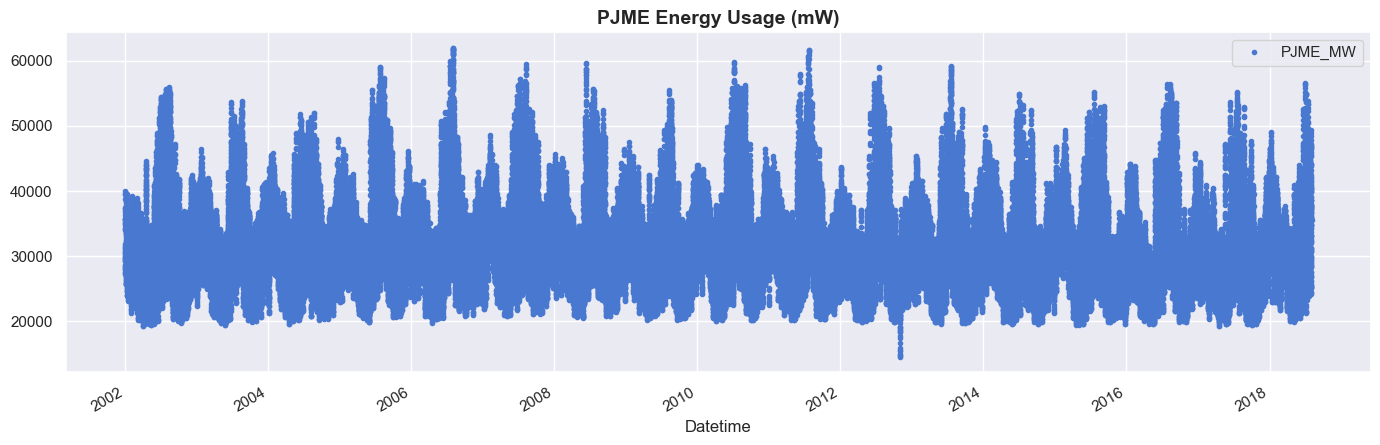

In [147]:
df.plot(
  style='.', 
  figsize=(15,5),
  title="PJME Energy Usage (mW)"
)

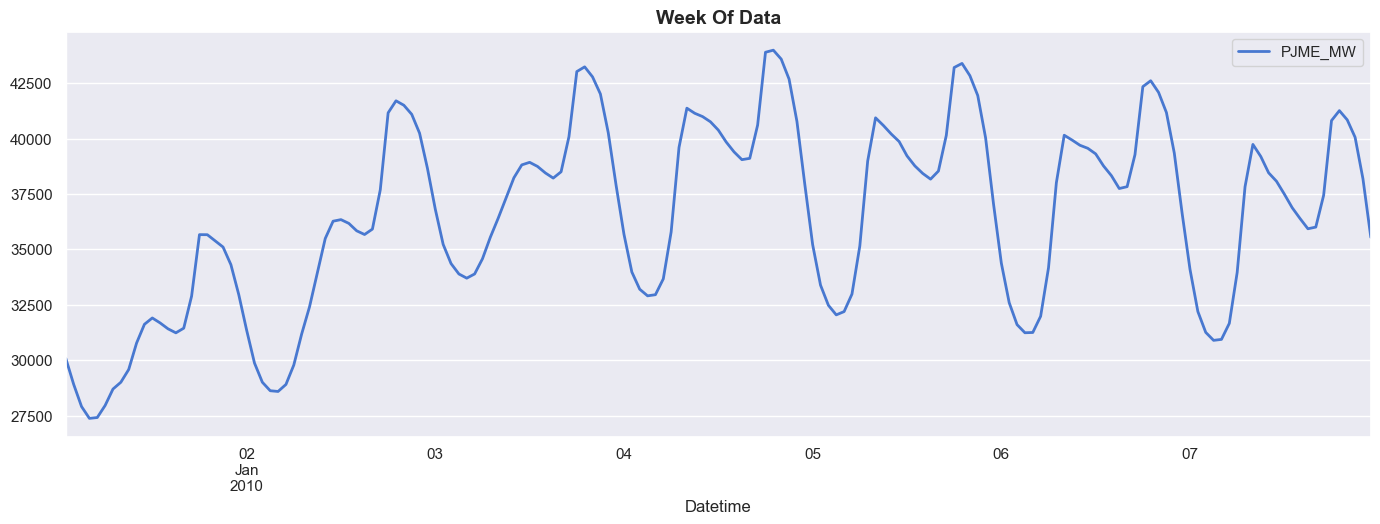

In [148]:
df.loc[(df.index > '2010-01-01') & (df.index < '2010-01-08')] \
    .plot(figsize=(15, 5), title='Week Of Data', linewidth=2)
plt.show()

## Feature Engineering for XGBoost

In [149]:
def create_features(df):
  df = df.copy()
  df['hour']       = df.index.hour
  df['dayofweek']  = df.index.dayofweek
  df['month']      = df.index.month
  # df['quarter']    = df.index.quarter
  df['year']       = df.index.year
  df['dayofyear']  = df.index.dayofyear
  # df['dayofmonth'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

df = create_features(df)
df.head(1)

,PJME_MW,hour,dayofweek,month,year,dayofyear,weekofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,1,1


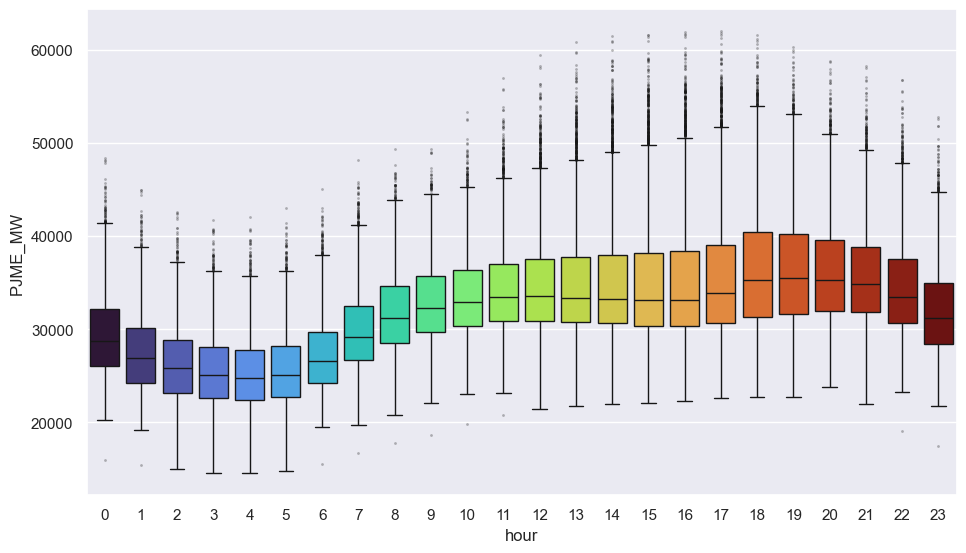

In [150]:
plt.figure(figsize=(10, 6))
sns.boxplot(
  data=df, 
  x='hour', y='PJME_MW',
  palette='turbo', hue="hour", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

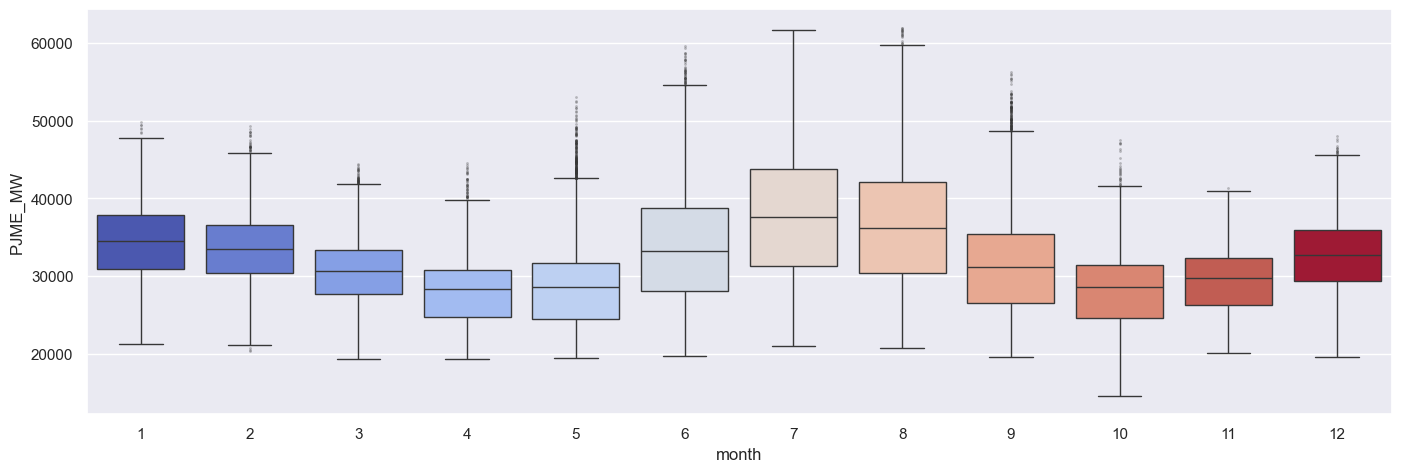

In [151]:
sns.boxplot(
  data=df, 
  x='month', y='PJME_MW',
  palette='coolwarm', hue="month", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

## Model Training

In [153]:
tscv = TimeSeriesSplit()

FEATURES = ['hour', 'dayofweek', 'month', 'quarter',
            'year', 'dayofyear', 'dayofmonth', 'weekofyear']
FEATURES = ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear']
TARGET = 'PJME_MW'

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

for fold, (train_idx, test_idx) in enumerate(tscv.split(df["PJME_MW"])):
  print(f"Fold {fold}:")
  print(f"  Train idx: {train_idx}")
  print(f"  Test idx:  {test_idx}")
  print(f"  No. of Train instances: {len(train_idx)}")
  print(f"  No. of Test instances:  {len(test_idx)}")

  # Slice dataset
  X_train = df[FEATURES].iloc[train_idx]
  X_test = df[FEATURES].iloc[test_idx]
  y_train = df[TARGET].iloc[train_idx]
  y_test = df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50, # prevent overfitting by stopping model if validation metric (RMSE) increases above previous rounds
    eval_metric='rmse'
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in mW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}mW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':     y_test.values,
    'predicted':  preds,
    'fold':       fold
  }, index=y_test.index)
  predictions = pd.concat([predictions, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} mW")

Fold 0:
  Train idx: [    0     1     2 ... 24228 24229 24230]
  Test idx:  [24231 24232 24233 ... 48455 48456 48457]
  No. of Train instances: 24231
  No. of Test instances:  24227
[0]	validation_0-rmse:6310.25282	validation_1-rmse:6541.50639
[100]	validation_0-rmse:4413.48410	validation_1-rmse:4855.05087
[200]	validation_0-rmse:3702.83220	validation_1-rmse:4230.04111
[300]	validation_0-rmse:3327.83950	validation_1-rmse:3894.86372
[400]	validation_0-rmse:3107.83086	validation_1-rmse:3737.01285
[500]	validation_0-rmse:2977.71420	validation_1-rmse:3662.58965
[600]	validation_0-rmse:2889.99506	validation_1-rmse:3623.03801
[700]	validation_0-rmse:2821.13369	validation_1-rmse:3594.53939
[800]	validation_0-rmse:2768.14283	validation_1-rmse:3566.16415
[900]	validation_0-rmse:2721.05757	validation_1-rmse:3551.14702
[999]	validation_0-rmse:2681.15007	validation_1-rmse:3540.69659
Fold 0 RMSE: 3540.7mW
Fold 1:
  Train idx: [    0     1     2 ... 48455 48456 48457]
  Test idx:  [48458 48459 48460

In [154]:
predictions[predictions["fold"] == 1]

,actual,predicted,fold
Datetime,,,
2007-07-13 14:00:00,44036.0,44403.210938,1
2007-07-13 15:00:00,44171.0,44403.210938,1
2007-07-13 16:00:00,43776.0,44403.210938,1
2007-07-13 17:00:00,43100.0,44578.500000,1
2007-07-13 18:00:00,42296.0,44610.542969,1
...,...,...,...
2010-04-18 02:00:00,22274.0,23547.828125,1
2010-04-18 03:00:00,21844.0,23109.521484,1
2010-04-18 04:00:00,21543.0,23109.521484,1


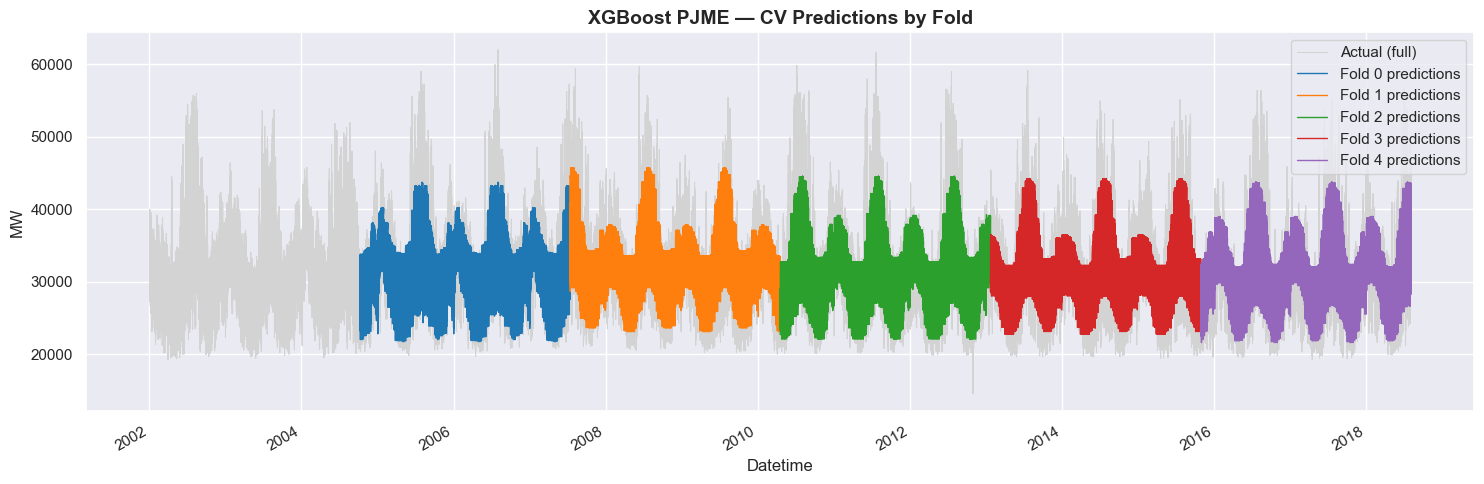

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

# Full actual series in the background
df[TARGET].plot(ax=ax, color='lightgray', label='Actual (full)', linewidth=0.75)

# Overlay each fold's predictions in a distinct color
colors = plt.cm.tab10.colors
for fold in predictions['fold'].unique():
  mask = predictions['fold'] == fold
  predictions.loc[mask, 'predicted'].plot(
    ax=ax, color=colors[fold], label=f'Fold {fold} predictions', linewidth=1
  )

ax.set_title('XGBoost PJME — CV Predictions by Fold')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='Datetime'>

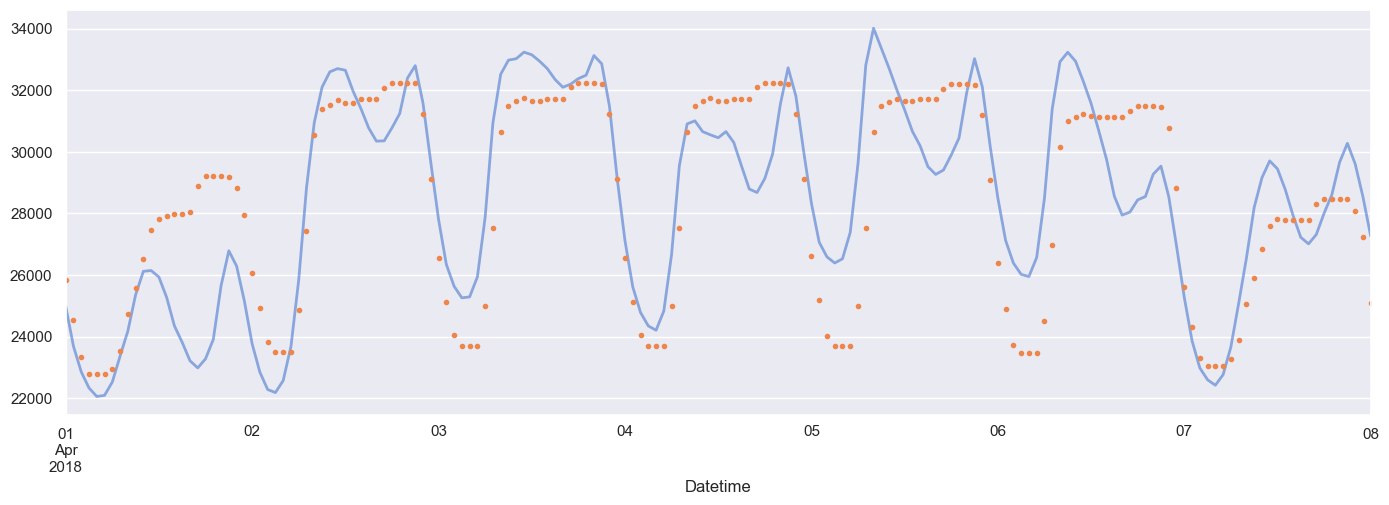

In [165]:
mask = (predictions.index >= '2018-04-01') & (predictions.index <= '2018-04-08')
predictions.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)

### Feature Importances

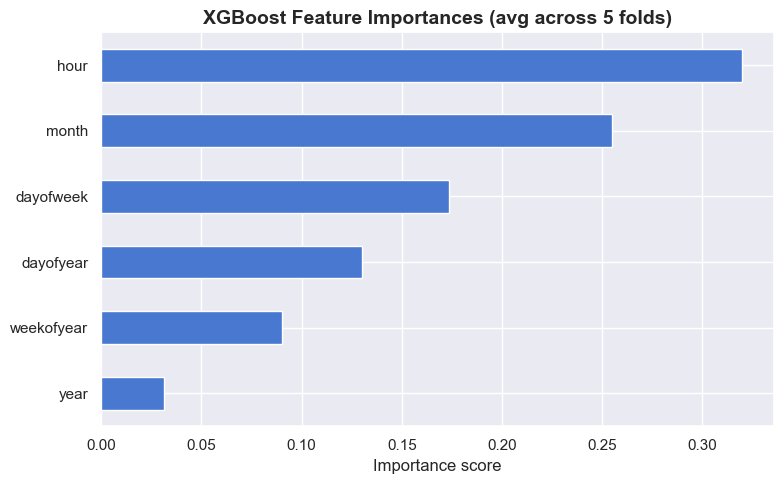

In [157]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Features like month and dayofyear are highly correlated. Removing month may cause the importance of dayofyear to spike. The raw feature importances are not always the most reliable metric to evaluate each individual feature, moreso how they all work together.

### Calculate Error

In [158]:
predictions["error"] = np.abs(predictions["actual"] - predictions["predicted"])
predictions["date"] = predictions.index.date
predictions.groupby("date")["error"].mean().sort_values(ascending=False).head(10)

date
2006-08-02    14254.804769
2011-07-22    13892.669189
2006-08-03    13876.609294
2011-07-23    12948.465576
2010-07-07    12443.804932
2006-08-01    12249.846436
2005-08-13    12227.629395
2005-08-14    12122.260742
2008-06-10    11898.271973
2016-08-13    11838.775228
Name: error, dtype: float64

**Most inaccurate dates:**  
2011-07-22, 2011-07-23, 2005-08-14, 2006-08-02, 2005-08-13, 2010-07-07, 2006-08-03, 2016-08-13, 2011-06-09, 2010-09-0